# Linear SVM Classifier for Founder Retention Prediction

This notebook trains a Linear Support Vector Machine (SVM) classifier to predict whether a founder will stay with or leave their startup.

**Experiment**: Linear SVM
**Kernel**: Linear
**Task**: Binary Classification (Stayed vs Left)

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import time
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"Experiment: Linear SVM")

Libraries imported successfully!
Experiment: Linear SVM


In [2]:
# Load preprocessed data
X_train_split = pd.read_csv('dataset/X_train_split.csv')
X_val_split = pd.read_csv('dataset/X_val_split.csv')
y_train_split = pd.read_csv('dataset/y_train_split.csv').values.ravel()
y_val_split = pd.read_csv('dataset/y_val_split.csv').values.ravel()

# Load full training data for final model
X_train_full = pd.read_csv('dataset/X_train_preprocessed.csv')
y_train_full = pd.read_csv('dataset/y_train.csv').values.ravel()

# Load test data
X_test = pd.read_csv('dataset/X_test_preprocessed.csv')

# Load test IDs
test_ids = pd.read_csv('dataset/test.csv')['founder_id']

# Load label encoder
with open('dataset/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

print("Data loaded successfully!")
print(f"Training set: {X_train_split.shape}")
print(f"Validation set: {X_val_split.shape}")
print(f"Full training set: {X_train_full.shape}")
print(f"Test set: {X_test.shape}")
print(f"Test IDs: {len(test_ids)}")

Data loaded successfully!
Training set: (47688, 26)
Validation set: (11923, 26)
Full training set: (59611, 26)
Test set: (14900, 26)
Test IDs: 14900


## 2. Train Linear SVM Model

In [3]:
# Initialize Linear SVM with default parameters
print("Training Linear SVM (kernel='linear')...")
print("This may take a few minutes...\n")

start_time = time.time()

# Create Linear SVM classifier
linear_svm = SVC(
    kernel='linear',
    C=1.0,
    random_state=42,
    verbose=1
)

# Train the model
linear_svm.fit(X_train_split, y_train_split)

training_time = time.time() - start_time

print(f"\n✓ Training completed in {training_time:.2f} seconds")
print(f"Number of support vectors: {len(linear_svm.support_vectors_)}")

Training Linear SVM (kernel='linear')...
This may take a few minutes...

[LibSVM].........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................*.....................................................*.......................................................................................................

## 3. Evaluate Model on Validation Set

In [4]:
# Make predictions on validation set
y_val_pred = linear_svm.predict(X_val_split)

# Calculate metrics
accuracy = accuracy_score(y_val_split, y_val_pred)
precision = precision_score(y_val_split, y_val_pred)
recall = recall_score(y_val_split, y_val_pred)
f1 = f1_score(y_val_split, y_val_pred)

print("="*60)
print("LINEAR SVM - VALIDATION SET PERFORMANCE")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*60)

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_val_split, y_val_pred, 
                          target_names=['Left', 'Stayed']))

LINEAR SVM - VALIDATION SET PERFORMANCE
Accuracy:  0.6966
Precision: 0.6977
Recall:    0.7438
F1-Score:  0.7200

Classification Report:
              precision    recall  f1-score   support

        Left       0.70      0.64      0.67      5670
      Stayed       0.70      0.74      0.72      6253

    accuracy                           0.70     11923
   macro avg       0.70      0.69      0.69     11923
weighted avg       0.70      0.70      0.70     11923



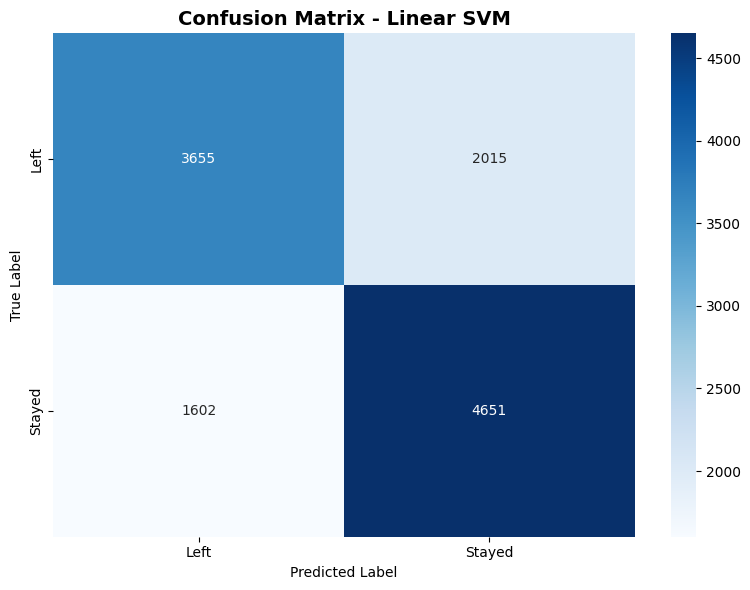


True Negatives:  3655
False Positives: 2015
False Negatives: 1602
True Positives:  4651


In [5]:
# Confusion Matrix
cm = confusion_matrix(y_val_split, y_val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Left', 'Stayed'],
            yticklabels=['Left', 'Stayed'])
plt.title('Confusion Matrix - Linear SVM', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives:  {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives:  {cm[1, 1]}")

## 4. Train Final Model on Full Training Data

In [6]:
# Train final model on all training data
print("Training final Linear SVM model on full training data...")
print("This may take a few minutes...\n")

start_time = time.time()

final_linear_svm = SVC(
    kernel='linear',
    C=1.0,
    random_state=42,
    verbose=1
)

final_linear_svm.fit(X_train_full, y_train_full)

final_training_time = time.time() - start_time

print(f"\n✓ Final model training completed in {final_training_time:.2f} seconds")
print(f"Number of support vectors: {len(final_linear_svm.support_vectors_)}")
print(f"Training samples used: {X_train_full.shape[0]}")

Training final Linear SVM model on full training data...
This may take a few minutes...

[LibSVM].......................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

## 5. Generate Predictions on Test Set

In [7]:
# Make predictions on test set
print("Generating predictions on test set...")
y_test_pred_encoded = final_linear_svm.predict(X_test)

# Convert predictions back to original labels
y_test_pred_labels = label_encoder.inverse_transform(y_test_pred_encoded)

print(f"✓ Predictions generated for {len(y_test_pred_labels)} test samples")
print(f"\nPrediction distribution:")
unique, counts = np.unique(y_test_pred_labels, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count} ({count/len(y_test_pred_labels)*100:.2f}%)")

Generating predictions on test set...
✓ Predictions generated for 14900 test samples

Prediction distribution:
  Left: 6561 (44.03%)
  Stayed: 8339 (55.97%)
✓ Predictions generated for 14900 test samples

Prediction distribution:
  Left: 6561 (44.03%)
  Stayed: 8339 (55.97%)


## 6. Save Results to CSV

In [8]:
# Create submission dataframe
submission_df = pd.DataFrame({
    'founder_id': test_ids,
    'retention_status': y_test_pred_labels
})

# Save to CSV
output_filename = 'test_result_linear_svm.csv'
submission_df.to_csv(output_filename, index=False)

print(f"✓ Results saved to '{output_filename}'")
print(f"\nSubmission file preview:")
display(submission_df.head(10))
print(f"\nTotal predictions: {len(submission_df)}")
print(f"File size: {submission_df.memory_usage(deep=True).sum() / 1024:.2f} KB")

✓ Results saved to 'test_result_linear_svm.csv'

Submission file preview:


,founder_id,retention_status
0,52685,Stayed
1,30585,Left
2,54656,Stayed
3,33442,Left
4,15667,Stayed
5,3496,Left
6,46775,Left
7,72645,Left
8,4941,Stayed
9,65181,Left



Total predictions: 14900
File size: 1020.42 KB


## 7. Summary

In [9]:
print("="*70)
print("LINEAR SVM TRAINING SUMMARY")
print("="*70)
print(f"\n📊 Model Configuration:")
print(f"   - Kernel: Linear")
print(f"   - Regularization (C): 1.0")
print(f"   - Features: {X_train_full.shape[1]}")
print(f"   - Training samples: {X_train_full.shape[0]}")

print(f"\n⏱️  Training Time:")
print(f"   - Validation model: {training_time:.2f} seconds")
print(f"   - Final model: {final_training_time:.2f} seconds")

print(f"\n📈 Validation Performance:")
print(f"   - Accuracy:  {accuracy:.4f}")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall:    {recall:.4f}")
print(f"   - F1-Score:  {f1:.4f}")

print(f"\n💾 Output:")
print(f"   - File: {output_filename}")
print(f"   - Test predictions: {len(submission_df)}")

print("\n" + "="*70)
print("✓ Linear SVM training completed successfully!")
print("="*70)

LINEAR SVM TRAINING SUMMARY

📊 Model Configuration:
   - Kernel: Linear
   - Regularization (C): 1.0
   - Features: 26
   - Training samples: 59611

⏱️  Training Time:
   - Validation model: 199.64 seconds
   - Final model: 323.65 seconds

📈 Validation Performance:
   - Accuracy:  0.6966
   - Precision: 0.6977
   - Recall:    0.7438
   - F1-Score:  0.7200

💾 Output:
   - File: test_result_linear_svm.csv
   - Test predictions: 14900

✓ Linear SVM training completed successfully!
